In [24]:
#!/usr/bin/env python3
"""
Scan CMIP6 SST model directories, compute basin-mean JJAS SST time series on
native ocean grids, define warming relative to each model's historical
1995–2014 climatological mean, and estimate the first year each warming
threshold is reached under a future scenario.

Designed for collections where:
- files are split yearly (e.g., 2020.nc, 2021.nc, ...)
- historical and scenario files are both stored within each model folder
- SST is usually 'tos'
- grids are curvilinear/native ocean grids with 2D lat/lon
- units may differ across datasets
- some models may be missing years or have awkward metadata

Outputs:
- basin_model_jjas_timeseries.csv
- basin_threshold_crossings_by_model.csv
- basin_mmm_jjas_timeseries.csv
- basin_threshold_crossings_mmm.csv
- basin_model_summary.csv
"""
from __future__ import annotations

from pathlib import Path
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import re


# ============================================================
# USER SETTINGS
# ============================================================

NETID = "k16v981"
ROOT = Path(f"/home/{NETID}/my_work/data/cmip6/sst")
OUTDIR = Path("./outputs/cmip6_basin_sst_thresholds")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Thresholds to test (warming relative to historical baseline)
THRESHOLDS_C = [1.0, 2.0, 3.0, 4.0]

# Season for analysis
SEASON_MONTHS = [6, 7, 8, 9]  # JJAS

# Historical climatology baseline
HIST_BASELINE_YEARS = (1995, 2014)

# Future scenario to analyze
PROJECTION_SCENARIO = "ssp370"

# Basin boxes (lon in degrees east or west; code converts to [-180, 180])
BASINS = {
    "arabian_gulf": {
        "lat_min": 24,
        "lat_max": 30,
        "lon_min": 48,
        "lon_max": 57,
    },
    "red_sea": {
        "lat_min": 12,
        "lat_max": 30,
        "lon_min": 32,
        "lon_max": 44,
    },
    "arabian_sea": {
        "lat_min": 5,
        "lat_max": 25,
        "lon_min": 56,
        "lon_max": 75,
    },

    "gulf_of_oman": {
        "lat_min": 22,
        "lat_max": 26,
        "lon_min": 56,
        "lon_max": 62,
    },
    "gulf_of_aden": {
        "lat_min": 11,
        "lat_max": 16,
        "lon_min": 43,
        "lon_max": 52,
    },
}

# Optional smoothing before threshold crossing
# 1 = none, 5 = 5-year trailing running mean
RUNNING_MEAN_YEARS = 1

# Recenter anomaly-like datasets to 0 over the historical baseline window
RECENTER_ANOMALIES_TO_BASELINE = True

# Minimum valid fraction of basin cells at the first time slice
MIN_VALID_CELL_FRAC = 0.10

# Candidate SST variable names, in priority order
VAR_CANDIDATES = [
    "tos",
    "sst",
    "sea_surface_temperature",
    "analysed_sst",
    "thetao",  # fallback only
]


# ============================================================
# HELPERS
# ============================================================

def _print(msg: str) -> None:
    print(msg, flush=True)


def find_model_dirs(root: Path) -> List[Path]:
    bad_names = {".ipynb_checkpoints", "__pycache__"}
    return sorted([
        p for p in root.iterdir()
        if p.is_dir() and p.name not in bad_names and not p.name.startswith(".")
    ])


def extract_year_from_name(path: Path) -> Optional[int]:
    m = re.search(r'(?<!\d)(19\d{2}|20\d{2}|21\d{2})(?!\d)', path.stem)
    if m:
        return int(m.group(1))
    return None


def list_candidate_files(model_dir: Path, dataset_type: str) -> List[Path]:
    files: List[Path] = []
    for ext in ("*.nc", "*.nc4", "*.cdf", "*.zarr"):
        files.extend(model_dir.rglob(ext))

    files = sorted(files)

    if dataset_type == "historical":
        hist_files = []
        for f in files:
            s = str(f).lower()
            yr = extract_year_from_name(f)

            # exclude hidden/checkpoint paths
            if "/.ipynb_checkpoints/" in s or s.endswith(".ipynb_checkpoints"):
                continue

            # exclude scenario-tagged files
            if any(tag in s for tag in ["ssp119", "ssp126", "ssp245", "ssp370", "ssp585"]):
                continue

            # require this to actually look like an SST file
            if "sst" not in s and "tos" not in s:
                continue

            # keep plain historical yearly files
            if yr is not None and yr <= 2014:
                hist_files.append(f)

        return hist_files

    elif dataset_type == "ssp370":
        scen_files = []
        for f in files:
            s = str(f).lower()
            yr = extract_year_from_name(f)

            if "/.ipynb_checkpoints/" in s or s.endswith(".ipynb_checkpoints"):
                continue

            # require this to actually look like an SST file
            if "sst" not in s and "tos" not in s:
                continue

            # identify future files by year instead of scenario tag
            if yr is None:
                continue

            if 2020 <= yr <= 2099:
                scen_files.append(f)

        return sorted(scen_files)


def guess_engine(path: Path) -> Optional[str]:
    if path.suffix == ".zarr":
        return "zarr"
    return None


def normalize_coord_names(ds: xr.Dataset) -> xr.Dataset:
    """
    Rename common coord names only when the target name does not already exist.
    This avoids collisions like latitude -> lat when lat already exists.
    """
    rename = {}

    if "lat" not in ds.coords and "lat" not in ds.dims:
        for cand in ["latitude", "nav_lat", "Latitude"]:
            if cand in ds.coords or cand in ds.dims:
                rename[cand] = "lat"
                break

    if "lon" not in ds.coords and "lon" not in ds.dims:
        for cand in ["longitude", "nav_lon", "Longitude"]:
            if cand in ds.coords or cand in ds.dims:
                rename[cand] = "lon"
                break

    if "time" not in ds.coords and "time" not in ds.dims:
        if "time_counter" in ds.coords or "time_counter" in ds.dims:
            rename["time_counter"] = "time"

    if rename:
        ds = ds.rename(rename)

    return ds


def maybe_decode_time(ds: xr.Dataset) -> xr.Dataset:
    if "time" not in ds.coords and "time" not in ds.dims:
        return ds
    try:
        return xr.decode_cf(ds)
    except Exception:
        return ds


def open_dataset_flex(path: Path) -> xr.Dataset:
    if path.suffix == ".zarr":
        ds = xr.open_zarr(path, consolidated=False)
        ds = normalize_coord_names(ds)
        ds = maybe_decode_time(ds)
        return ds

    errors = []

    for engine in [None, "netcdf4", "h5netcdf", "scipy"]:
        try:
            kwargs = {"decode_times": True}
            if engine is not None:
                kwargs["engine"] = engine
            ds = xr.open_dataset(path, **kwargs)
            ds = normalize_coord_names(ds)
            ds = maybe_decode_time(ds)
            return ds
        except Exception as e:
            errors.append(f"{engine}: {e}")

    raise ValueError(f"All open attempts failed for {path.name} | " + " | ".join(errors))


def open_model_dataset(files: List[Path]) -> xr.Dataset:
    """
    Open all files for a model. Tries open_mfdataset(by_coords) first,
    then falls back to opening one-by-one and concatenating along time.
    """
    if len(files) == 1:
        return open_dataset_flex(files[0])

    netcdfs = sorted([f for f in files if f.suffix in {".nc", ".nc4", ".cdf"}])
    zarrs = [f for f in files if f.suffix == ".zarr"]

    if zarrs and not netcdfs:
        return open_dataset_flex(zarrs[0])

    if not netcdfs and zarrs:
        return open_dataset_flex(zarrs[0])

    try:
        return xr.open_mfdataset(
            [str(f) for f in netcdfs],
            combine="by_coords",
            preprocess=normalize_coord_names,
            decode_times=True,
            parallel=False,
            use_cftime=True,
            chunks = chunk(dict(time=-1))
        )
    except Exception:
        pass

    datasets = []
    file_errors = []

    for f in netcdfs:
        try:
            ds = open_dataset_flex(f)
            datasets.append(ds)
        except Exception as e:
            file_errors.append(f"{f.name}: {e}")

    if not datasets:
        preview = "\n".join(file_errors[:5])
        raise ValueError("Could not open any files for this model. First errors:\n" + preview)

    def first_time(ds: xr.Dataset):
        if "time" in ds.coords and ds["time"].size > 0:
            return ds["time"].values[0]
        return 0

    datasets = sorted(datasets, key=first_time)

    try:
        return xr.concat(datasets, dim="time")
    except Exception as e:
        raise ValueError(f"manual concat failed: {e}")


def choose_sst_var(ds: xr.Dataset) -> Optional[str]:
    """
    Prefer actual gridded SST-like variables, not 1D metadata.
    """
    candidates = []

    for v in ds.data_vars:
        low = v.lower()
        if v in VAR_CANDIDATES or "sst" in low or low == "tos" or "sea_surface_temperature" in low:
            da = ds[v]
            dims_lower = {d.lower() for d in da.dims}

            spatial_score = 0
            if "time" in dims_lower:
                spatial_score += 1
            if "lat" in dims_lower or "latitude" in dims_lower:
                spatial_score += 1
            if "lon" in dims_lower or "longitude" in dims_lower:
                spatial_score += 1
            if any(d in dims_lower for d in ["x", "y", "i", "j", "nlat", "nlon"]):
                spatial_score += 1

            candidates.append((spatial_score, da.ndim, v))

    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda x: (x[0], x[1]), reverse=True)
    return candidates[0][2]


def drop_extra_dims(da: xr.DataArray) -> xr.DataArray:
    """
    Keep native ocean-grid spatial dims.
    Only collapse singleton dims or known optional dims.
    """
    spatial_like = {"time", "lat", "lon", "i", "j", "x", "y", "nlat", "nlon"}

    squeeze_dims = [d for d in da.dims if da.sizes.get(d, 1) == 1]
    if squeeze_dims:
        da = da.squeeze(drop=True)

    extra_dims = [d for d in da.dims if d.lower() not in spatial_like]

    for dim in extra_dims:
        if da.sizes[dim] == 1:
            da = da.squeeze(dim, drop=True)
        else:
            if dim.lower() in {
                "lev", "olevel", "depth", "member", "member_id",
                "bnds", "vertices", "vertex", "nvertex"
            }:
                da = da.isel({dim: 0})
            else:
                raise ValueError(f"Unrecognized extra dimension that should not be dropped: {dim}")

    return da

def prepare_model_sst(model_dir: Path, scenario: str) -> Tuple[Optional[xr.DataArray], Dict]:
    info = {
        "files_found": 0,
        "var_name": "",
        "units_source": "",
        "anomaly_like": None,
        "years_min": None,
        "years_max": None,
        "status": "ok",
        "reason": "",
    }

    files = list_candidate_files(model_dir, dataset_type=scenario)
    info["files_found"] = len(files)

    if not files:
        info["status"] = "skipped"
        info["reason"] = f"no_{scenario}_files"
        return None, info

    try:
        ds = open_model_dataset(files)
    except Exception as e:
        info["status"] = "skipped"
        info["reason"] = f"{scenario}_open_failed: {e}"
        return None, info

    ds = normalize_coord_names(ds)

    if "time" not in ds.coords and "time" not in ds.dims:
        info["status"] = "skipped"
        info["reason"] = f"{scenario}_no_time_coord"
        return None, info

    var = choose_sst_var(ds)
    if var is None:
        info["status"] = "skipped"
        info["reason"] = f"{scenario}_no_sst_variable_found"
        return None, info

    da = ds[var]
    info["var_name"] = var

    try:
        da = drop_extra_dims(da)
    except Exception as e:
        info["status"] = "skipped"
        info["reason"] = f"{scenario}_drop_extra_dims_failed: {e}"
        return None, info

    dims_lower = {d.lower() for d in da.dims}
    has_time = "time" in dims_lower
    has_native_xy = any(d in dims_lower for d in {"i", "x", "nlon"}) and any(d in dims_lower for d in {"j", "y", "nlat"})
    has_rectilinear = "lat" in dims_lower and "lon" in dims_lower

    if not has_time or not (has_native_xy or has_rectilinear):
        info["status"] = "skipped"
        info["reason"] = f"{scenario}_not_spatial_sst_dims: {da.dims}"
        return None, info

    try:
        _ = find_lat_lon_coords(da)
    except Exception as e:
        info["status"] = "skipped"
        info["reason"] = f"{scenario}_latlon_not_found: {e}"
        return None, info

    da, units_source = detect_units_and_convert_to_celsius(da)
    info["units_source"] = units_source

    anomaly_like = detect_anomaly_like(da)
    info["anomaly_like"] = anomaly_like

    years = np.unique(da["time"].dt.year.values)
    if len(years) == 0:
        info["status"] = "skipped"
        info["reason"] = f"{scenario}_no_valid_years"
        return None, info

    info["years_min"] = int(np.nanmin(years))
    info["years_max"] = int(np.nanmax(years))

    return da, info
    

def detect_units_and_convert_to_celsius(da: xr.DataArray) -> Tuple[xr.DataArray, str]:
    units = str(da.attrs.get("units", "")).strip().lower()
    sample = da

    if "time" in sample.dims and sample.sizes["time"] > 24:
        sample = sample.isel(time=slice(0, 24))

    try:
        approx_mean = float(sample.mean(skipna=True).compute())
    except Exception:
        approx_mean = float(sample.mean(skipna=True))

    converted_from = "unknown"

    if units in {"k", "kelvin"}:
        da = da - 273.15
        converted_from = "K"
    elif units in {"degc", "degree_celsius", "degrees_celsius", "c", "°c", "degc"}:
        converted_from = "C"
    else:
        if approx_mean > 150:
            da = da - 273.15
            converted_from = "K_heuristic"
        else:
            converted_from = "C_or_anomaly_heuristic"

    da.attrs["units"] = "C"
    return da, converted_from


def detect_anomaly_like(da: xr.DataArray) -> bool:
    name_bits = " ".join([
        str(da.name or ""),
        str(da.attrs.get("long_name", "")),
        str(da.attrs.get("standard_name", "")),
        str(da.attrs.get("description", "")),
    ]).lower()

    if "anom" in name_bits or "anomaly" in name_bits:
        return True

    sample = da
    if "time" in sample.dims and sample.sizes["time"] > 24:
        sample = sample.isel(time=slice(0, 24))

    try:
        q05 = float(sample.quantile(0.05, skipna=True).compute())
        q95 = float(sample.quantile(0.95, skipna=True).compute())
        meanv = float(sample.mean(skipna=True).compute())
    except Exception:
        q05 = float(sample.quantile(0.05, skipna=True))
        q95 = float(sample.quantile(0.95, skipna=True))
        meanv = float(sample.mean(skipna=True))

    if abs(meanv) < 5 and q05 < 0 and q95 < 15:
        return True

    return False


def find_lat_lon_coords(da: xr.DataArray) -> Tuple[xr.DataArray, xr.DataArray]:
    lat = None
    lon = None

    for name in da.coords:
        low = name.lower()
        if low in {"lat", "latitude", "nav_lat"}:
            lat = da[name]
        if low in {"lon", "longitude", "nav_lon"}:
            lon = da[name]

    if lat is None or lon is None:
        raise ValueError("Could not find 2D or 1D lat/lon coordinates")

    return lat, lon


def basin_mean_curvilinear(da: xr.DataArray, basin: Dict[str, float]) -> xr.DataArray:
    """
    Compute area-weighted basin mean on a native curvilinear grid.
    Works for:
    - (time, j, i)
    - (time, y, x)
    - also works on rectilinear if lat/lon coords are present
    """
    lat, lon = find_lat_lon_coords(da)

    # Normalize longitude to [-180, 180]
    lon_norm = ((lon + 180) % 360) - 180

    mask = (
        (lat >= basin["lat_min"]) &
        (lat <= basin["lat_max"]) &
        (lon_norm >= basin["lon_min"]) &
        (lon_norm <= basin["lon_max"])
    )

    masked = da.where(mask)

    # Cos(lat) weighting
    weights = np.cos(np.deg2rad(lat)).where(mask)

    spatial_dims = [d for d in da.dims if d != "time"]

    numerator = (masked * weights).sum(dim=spatial_dims, skipna=True)
    denominator = weights.sum(dim=spatial_dims, skipna=True)

    return numerator / denominator


def valid_cell_fraction_curvilinear(da: xr.DataArray, basin: Dict[str, float]) -> float:
    lat, lon = find_lat_lon_coords(da)
    lon_norm = ((lon + 180) % 360) - 180

    mask = (
        (lat >= basin["lat_min"]) &
        (lat <= basin["lat_max"]) &
        (lon_norm >= basin["lon_min"]) &
        (lon_norm <= basin["lon_max"])
    )

    if "time" in da.dims:
        test = da.isel(time=0).where(mask)
    else:
        test = da.where(mask)

    total = int(mask.sum().values)
    if total == 0:
        return 0.0

    valid = int(test.notnull().sum().values)
    return valid / total


def jjas_yearly_mean(da: xr.DataArray) -> xr.DataArray:
    da = da.sel(time=da["time"].dt.month.isin(SEASON_MONTHS))
    yearly = da.groupby("time.year").mean("time", skipna=True)
    return yearly


def trailing_running_mean(da: xr.DataArray, window: int) -> xr.DataArray:
    if window <= 1:
        return da
    return da.rolling(year=window, min_periods=window).mean()


def first_crossing_year(series: xr.DataArray, threshold: float) -> Optional[int]:
    vals = series.values
    years = series["year"].values

    mask = np.isfinite(vals) & (vals >= threshold)
    if not np.any(mask):
        return None
    return int(years[np.argmax(mask)])


def baseline_mean(series: xr.DataArray, start: int, end: int) -> float:
    sub = series.sel(year=slice(start, end))
    if sub.size == 0:
        raise ValueError(f"No baseline data in {start}-{end}")
    return float(sub.mean(skipna=True).values)


# ============================================================
# CORE PROCESSING
# ============================================================

def process_model(model_dir: Path) -> Tuple[pd.DataFrame, pd.DataFrame, Dict]:
    model = model_dir.name
    summary = {
        "model": model,
        "status": "ok",
        "reason": "",
        "historical_files_found": 0,
        "projection_files_found": 0,
        "historical_var_name": "",
        "projection_var_name": "",
        "historical_units_source": "",
        "projection_units_source": "",
        "historical_anomaly_like": None,
        "projection_anomaly_like": None,
        "historical_years_min": None,
        "historical_years_max": None,
        "projection_years_min": None,
        "projection_years_max": None,
    }

    # -----------------------------
    # historical
    # -----------------------------
    hist_da, hist_info = prepare_model_sst(model_dir, "historical")
    summary["historical_files_found"] = hist_info["files_found"]
    summary["historical_var_name"] = hist_info["var_name"]
    summary["historical_units_source"] = hist_info["units_source"]
    summary["historical_anomaly_like"] = hist_info["anomaly_like"]
    summary["historical_years_min"] = hist_info["years_min"]
    summary["historical_years_max"] = hist_info["years_max"]

    if hist_da is None:
        summary["status"] = "skipped"
        summary["reason"] = hist_info["reason"]
        return pd.DataFrame(), pd.DataFrame(), summary

    # -----------------------------
    # projection
    # -----------------------------
    proj_da, proj_info = prepare_model_sst(model_dir, PROJECTION_SCENARIO)
    summary["projection_files_found"] = proj_info["files_found"]
    summary["projection_var_name"] = proj_info["var_name"]
    summary["projection_units_source"] = proj_info["units_source"]
    summary["projection_anomaly_like"] = proj_info["anomaly_like"]
    summary["projection_years_min"] = proj_info["years_min"]
    summary["projection_years_max"] = proj_info["years_max"]

    if proj_da is None:
        summary["status"] = "skipped"
        summary["reason"] = proj_info["reason"]
        return pd.DataFrame(), pd.DataFrame(), summary

    model_rows = []
    crossing_rows = []
    usable_any = False

    for basin_name, basin_spec in BASINS.items():
        try:
            hist_frac = valid_cell_fraction_curvilinear(hist_da, basin_spec)
            proj_frac = valid_cell_fraction_curvilinear(proj_da, basin_spec)
        except Exception:
            continue

        if hist_frac < MIN_VALID_CELL_FRAC or proj_frac < MIN_VALID_CELL_FRAC:
            continue

        try:
            hist_ts = basin_mean_curvilinear(hist_da, basin_spec)
            proj_ts = basin_mean_curvilinear(proj_da, basin_spec)

            hist_jjas = jjas_yearly_mean(hist_ts)
            proj_jjas = jjas_yearly_mean(proj_ts)
        except Exception:
            continue

        if hist_jjas.size == 0 or proj_jjas.size == 0:
            continue

        # Historical climatological baseline: 1995–2014
                # Historical JJAS climatology baseline: 1995–2014
        try:
            hist_clim = baseline_mean(hist_jjas, *HIST_BASELINE_YEARS)
            warming = proj_jjas - hist_clim
        except Exception:
            continue

        warming = trailing_running_mean(warming, RUNNING_MEAN_YEARS)
        usable_any = True

        for y, raw_val, warm_val in zip(
            proj_jjas["year"].values,
            proj_jjas.values,
            warming.values,
        ):
            model_rows.append({
                "model": model,
                "basin": basin_name,
                "year": int(y),
                "jjas_mean_sst_C": float(raw_val) if np.isfinite(raw_val) else np.nan,
                "warming_C": float(warm_val) if np.isfinite(warm_val) else np.nan,
                "historical_climatology_1995_2014_C": hist_clim,
                "projection_scenario": PROJECTION_SCENARIO,
            })

        for thr in THRESHOLDS_C:
            yr = first_crossing_year(warming, thr)
            crossing_rows.append({
                "model": model,
                "basin": basin_name,
                "threshold_C": thr,
                "first_year": yr,
                "projection_scenario": PROJECTION_SCENARIO,
            })

    if not usable_any:
        summary["status"] = "skipped"
        summary["reason"] = "no_usable_basin_data"
        return pd.DataFrame(), pd.DataFrame(), summary

    return pd.DataFrame(model_rows), pd.DataFrame(crossing_rows), summary


def build_mmm(model_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if model_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    mmm = (
        model_df
        .dropna(subset=["warming_C"])
        .groupby(["basin", "year"], as_index=False)
        .agg(
            mmm_warming_C=("warming_C", "mean"),
            model_count=("warming_C", "count"),
            mmm_raw_sst_C=("jjas_mean_sst_C", "mean"),
        )
    )

    crossing_rows = []
    for basin, g in mmm.groupby("basin"):
        g = g.sort_values("year")
        years = g["year"].to_numpy()
        vals = g["mmm_warming_C"].to_numpy()

        for thr in THRESHOLDS_C:
            mask = np.isfinite(vals) & (vals >= thr)
            yr = int(years[np.argmax(mask)]) if np.any(mask) else None
            crossing_rows.append({
                "basin": basin,
                "threshold_C": thr,
                "first_year_mmm": yr,
            })

    return mmm, pd.DataFrame(crossing_rows)


# ============================================================
# MAIN
# ============================================================

def main() -> None:
    _print(f"Scanning model directories in: {ROOT}")
    model_dirs = find_model_dirs(ROOT)
    _print(f"Found {len(model_dirs)} model directories")
    _print(f"Using historical baseline: {HIST_BASELINE_YEARS[0]}-{HIST_BASELINE_YEARS[1]}")
    _print(f"Projection scenario: {PROJECTION_SCENARIO}")

    all_model_rows = []
    all_crossing_rows = []
    summaries = []

    for i, model_dir in enumerate(model_dirs, start=1):
        _print(f"[{i}/{len(model_dirs)}] Processing {model_dir.name}")
        model_df, cross_df, summary = process_model(model_dir)
        summaries.append(summary)

        if not model_df.empty:
            all_model_rows.append(model_df)
        if not cross_df.empty:
            all_crossing_rows.append(cross_df)

        if summary["status"] != "ok":
            _print(f"  -> {summary['status']}: {summary['reason']}")

    summary_df = pd.DataFrame(summaries).sort_values(["status", "model"])
    summary_path = OUTDIR / "basin_model_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    if not all_model_rows:
        _print("No usable model data found. Check basin boxes, variable names, or file patterns.")
        _print(f"Summary written to: {summary_path}")
        return

    model_df = (
        pd.concat(all_model_rows, ignore_index=True)
        .sort_values(["basin", "model", "year"])
    )

    crossing_df = (
        pd.concat(all_crossing_rows, ignore_index=True)
        .sort_values(["basin", "threshold_C", "model"])
        if all_crossing_rows else pd.DataFrame()
    )

    model_ts_path = OUTDIR / "basin_model_jjas_timeseries.csv"
    crossing_model_path = OUTDIR / "basin_threshold_crossings_by_model.csv"

    model_df.to_csv(model_ts_path, index=False)
    if not crossing_df.empty:
        crossing_df.to_csv(crossing_model_path, index=False)

    mmm_df, mmm_cross_df = build_mmm(model_df)

    mmm_ts_path = OUTDIR / "basin_mmm_jjas_timeseries.csv"
    mmm_cross_path = OUTDIR / "basin_threshold_crossings_mmm.csv"

    if not mmm_df.empty:
        mmm_df.to_csv(mmm_ts_path, index=False)
    if not mmm_cross_df.empty:
        mmm_cross_df.to_csv(mmm_cross_path, index=False)

    _print("\nDone.")
    _print(f"Summary:                 {summary_path}")
    _print(f"Model JJAS timeseries:   {model_ts_path}")
    _print(f"Model crossings:         {crossing_model_path}")
    _print(f"MMM timeseries:          {mmm_ts_path}")
    _print(f"MMM crossings:           {mmm_cross_path}")

    ok_n = int((summary_df["status"] == "ok").sum())
    skip_n = int((summary_df["status"] != "ok").sum())
    _print(f"\nUsable models: {ok_n}")
    _print(f"Skipped models: {skip_n}")

    if not mmm_cross_df.empty:
        _print("\nMMM first threshold crossings:")
        _print(mmm_cross_df.to_string(index=False))


if __name__ == "__main__":
    main()

Scanning model directories in: /home/k16v981/my_work/data/cmip6/sst
Found 9 model directories
Using historical baseline: 1995-2014
Projection scenario: ssp370
[1/9] Processing canesm5
[2/9] Processing cmcc_cm2_sr5
[3/9] Processing cnrm_esm2_1
[4/9] Processing ec_earth3_veg_lr
[5/9] Processing fgoals_g3
[6/9] Processing iitm_esm
[7/9] Processing miroc6
[8/9] Processing mpi_esm1_2_lr
[9/9] Processing noresm2_mm

Done.
Summary:                 outputs/cmip6_basin_sst_thresholds/basin_model_summary.csv
Model JJAS timeseries:   outputs/cmip6_basin_sst_thresholds/basin_model_jjas_timeseries.csv
Model crossings:         outputs/cmip6_basin_sst_thresholds/basin_threshold_crossings_by_model.csv
MMM timeseries:          outputs/cmip6_basin_sst_thresholds/basin_mmm_jjas_timeseries.csv
MMM crossings:           outputs/cmip6_basin_sst_thresholds/basin_threshold_crossings_mmm.csv

Usable models: 9
Skipped models: 0

MMM first threshold crossings:
       basin  threshold_C  first_year_mmm
arabian_gul


CMIP6 basin SST warming summary
--------------------------------
Red Sea        :  8 models, 2020–2099
Gulf of Aden   :  9 models, 2020–2099
Gulf of Oman   :  9 models, 2020–2099
Persian Gulf   :  8 models, 2020–2099

Saved PNG: ../figures/sst_exceedences/cmip6_basin_sst_warming_spread_ssp370.png
Saved PDF: ../figures/sst_exceedences/cmip6_basin_sst_warming_spread_ssp370.pdf


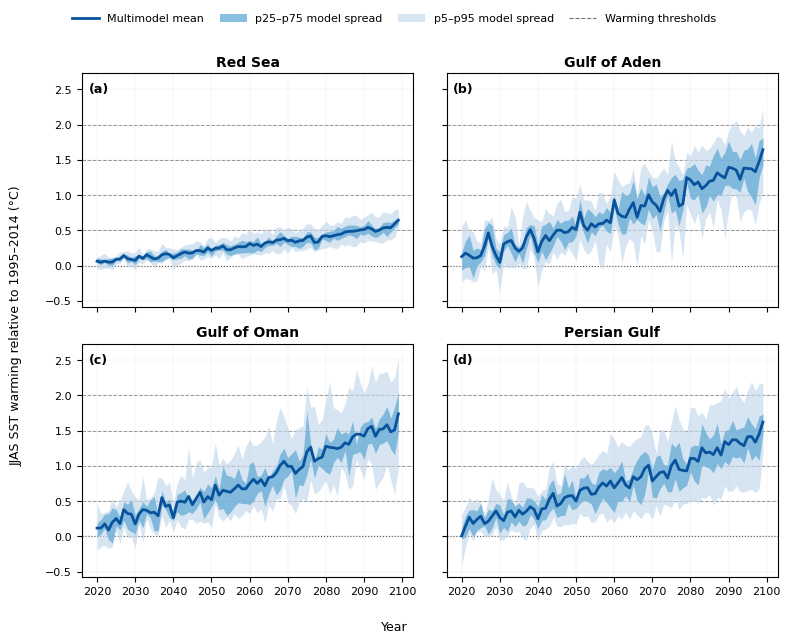

In [3]:
#!/usr/bin/env python3
# coding: utf-8

"""
SI FIGURE — CMIP6 BASIN SST WARMING AND MODEL SPREAD

Four-panel SSP3-7.0 figure showing JJAS basin SST warming relative to
the 1995–2014 climatology.

For each basin:
    solid line     = multimodel mean (MMM)
    dark blue band = interquartile model spread (p25–p75)
    light blue band = broad model spread (p5–p95)

Internal basin key "arabian_gulf" is labeled "Persian Gulf" in the figure.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# SETTINGS
# ============================================================

OUTDIR = Path("./outputs/cmip6_basin_sst_thresholds")
TS_FILE = OUTDIR / "basin_model_jjas_timeseries.csv"

FIG_DIR = Path("../figures/sst_exceedences")
FIG_DIR.mkdir(parents=True, exist_ok=True)

PNG_OUT = FIG_DIR / "cmip6_basin_sst_warming_spread_ssp370.png"
PDF_OUT = FIG_DIR / "cmip6_basin_sst_warming_spread_ssp370.pdf"

THRESHOLDS = [0.5, 1.0, 1.5, 2.0]

# Internal keys -> manuscript-facing names
BASINS = {
    "red_sea": "Red Sea",
    "gulf_of_aden": "Gulf of Aden",
    "gulf_of_oman": "Gulf of Oman",
    "arabian_gulf": "Persian Gulf",
}

# Desired panel order
BASIN_ORDER = [
    "red_sea",
    "gulf_of_aden",
    "gulf_of_oman",
    "arabian_gulf",
]


# ============================================================
# STYLE
# ============================================================

ERL_RC = {
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "savefig.transparent": False,
}

mpl.rcParams.update(ERL_RC)

# Blues requested for model spread
LIGHT_BLUE = "#c6dbef"
DARK_BLUE = "#6baed6"
MMM_BLUE = "#08519c"


# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(TS_FILE)

if df.empty:
    raise ValueError(f"No data found in {TS_FILE}")

required = {"basin", "model", "year", "warming_C"}
missing = required.difference(df.columns)

if missing:
    raise ValueError(
        f"Missing required columns in {TS_FILE}: {sorted(missing)}"
    )


# ============================================================
# CHECK BASINS
# ============================================================

available_basins = set(df["basin"].unique())

for basin in BASIN_ORDER:
    if basin not in available_basins:
        raise ValueError(
            f"Requested basin '{basin}' not found.\n"
            f"Available basins: {sorted(available_basins)}"
        )


# ============================================================
# COMPUTE YEARLY MULTIMODEL STATISTICS
# ============================================================

def calculate_model_spread(sub):
    """
    Calculate across-model statistics independently for each year.
    """

    stats = (
        sub.groupby("year")["warming_C"]
        .agg(
            mmm="mean",
            n_models="count",
            p05=lambda x: np.nanpercentile(x, 5),
            p25=lambda x: np.nanpercentile(x, 25),
            p75=lambda x: np.nanpercentile(x, 75),
            p95=lambda x: np.nanpercentile(x, 95),
        )
        .reset_index()
        .sort_values("year")
    )

    return stats


basin_stats = {}

print("\nCMIP6 basin SST warming summary")
print("--------------------------------")

for basin in BASIN_ORDER:

    sub = df[df["basin"] == basin].copy()

    stats = calculate_model_spread(sub)

    basin_stats[basin] = stats

    print(
        f"{BASINS[basin]:15s}: "
        f"{sub['model'].nunique():2d} models, "
        f"{int(stats['year'].min())}–{int(stats['year'].max())}"
    )


# ============================================================
# COMMON AXIS LIMITS
# ============================================================

all_low = np.concatenate([
    basin_stats[b]["p05"].to_numpy()
    for b in BASIN_ORDER
])

all_high = np.concatenate([
    basin_stats[b]["p95"].to_numpy()
    for b in BASIN_ORDER
])

ymin = min(
    np.nanmin(all_low),
    0.0,
)

ymax = max(
    np.nanmax(all_high),
    max(THRESHOLDS),
)

yrange = ymax - ymin

YLIM = (
    ymin - 0.06 * yrange,
    ymax + 0.07 * yrange,
)


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8.0, 6.3),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

panel_labels = ["(a)", "(b)", "(c)", "(d)"]


for i, basin in enumerate(BASIN_ORDER):

    ax = axes[i]
    stats = basin_stats[basin]

    year = stats["year"].to_numpy()

    # --------------------------------------------------------
    # Outer model spread: p5–p95
    # --------------------------------------------------------

    ax.fill_between(
        year,
        stats["p05"],
        stats["p95"],
        color=LIGHT_BLUE,
        alpha=0.70,
        linewidth=0,
        zorder=1,
    )

    # --------------------------------------------------------
    # Inner model spread: p25–p75
    # --------------------------------------------------------

    ax.fill_between(
        year,
        stats["p25"],
        stats["p75"],
        color=DARK_BLUE,
        alpha=0.80,
        linewidth=0,
        zorder=2,
    )

    # --------------------------------------------------------
    # Multimodel mean
    # --------------------------------------------------------

    ax.plot(
        year,
        stats["mmm"],
        color=MMM_BLUE,
        linewidth=2.0,
        zorder=4,
    )

    # --------------------------------------------------------
    # Warming thresholds
    # --------------------------------------------------------

    for threshold in THRESHOLDS:
        ax.axhline(
            threshold,
            color="0.45",
            linestyle="--",
            linewidth=0.7,
            alpha=0.75,
            zorder=0,
        )

    ax.axhline(
        0,
        color="0.30",
        linestyle=":",
        linewidth=0.8,
        zorder=0,
    )

    # --------------------------------------------------------
    # Cosmetics
    # --------------------------------------------------------

    ax.set_ylim(YLIM)

    ax.grid(
        True,
        linewidth=0.35,
        alpha=0.25,
        zorder=-10,
    )

    ax.set_title(
        BASINS[basin],
        fontweight="bold",
        pad=5,
    )

    ax.text(
        0.02,
        0.96,
        panel_labels[i],
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        fontweight="bold",
    )


# ============================================================
# SHARED LABELS
# ============================================================

fig.supxlabel(
    "Year",
    fontsize=9,
)

fig.supylabel(
    "JJAS SST warming relative to 1995–2014 (°C)",
    fontsize=9,
)


# ============================================================
# LEGEND
# ============================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        color=MMM_BLUE,
        linewidth=2.0,
        label="Multimodel mean",
    ),
    Patch(
        facecolor=DARK_BLUE,
        alpha=0.80,
        edgecolor="none",
        label="p25–p75 model spread",
    ),
    Patch(
        facecolor=LIGHT_BLUE,
        alpha=0.70,
        edgecolor="none",
        label="p5–p95 model spread",
    ),
    Line2D(
        [0],
        [0],
        color="0.45",
        linestyle="--",
        linewidth=0.8,
        label="Warming thresholds",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    frameon=False,
    fontsize=8,
    handlelength=2.4,
    columnspacing=1.4,
)


# ============================================================
# LAYOUT / SAVE
# ============================================================

fig.subplots_adjust(
    left=0.11,
    right=0.98,
    bottom=0.10,
    top=0.90,
    wspace=0.10,
    hspace=0.16,
)

fig.savefig(
    PNG_OUT,
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PDF_OUT,
    dpi=300,
    bbox_inches="tight",
)

print(f"\nSaved PNG: {PNG_OUT}")
print(f"Saved PDF: {PDF_OUT}")

plt.show()